<a href="https://colab.research.google.com/github/sachin-op/PyTorch_Basic_to_Advanced/blob/main/Neural_Network_Clasisification_with_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Architecture of a classification neural network
* A classification problem involves predicting whether something is one thing or another.



| Hyperparameter | Binary Classification | Multiclass Classification |
|----------------|----------------------|---------------------------|
| Input layer shape (in_features) | Same as number of features (e.g. 5 for age, sex, height, weight, smoking status in heart disease prediction) | Same as binary classification |
| Hidden layer(s) | Problem specific, minimum = 1, maximum = unlimited | Same as binary classification |
| Neurons per hidden layer | Problem specific, generally 10 to 512 | Same as binary classification |
| Output layer shape (out_features) | 1 (one class or the other) | 1 per class (e.g. 3 for food, person or dog photo) |
| Hidden layer activation | Usually ReLU (rectified linear unit) but can be many others | Same as binary classification |
| Output activation | Sigmoid (`torch.sigmoid` in PyTorch) | Softmax (`torch.softmax` in PyTorch) |
| Loss function | Binary crossentropy (`torch.nn.BCELoss` in PyTorch) | Cross entropy (`torch.nn.CrossEntropyLoss` in PyTorch) |
| Optimizer | SGD (stochastic gradient descent), Adam (see `torch.optim` for more options) | Same as binary classification |

# 1. Make Classification Data with make_circles and Prepare for Modeling


Step 1: Import Required Libraries

In [102]:
# Import libraries
import torch
import sklearn
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_circles
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

Step 2: Generate the Circle Dataset

In [103]:
# Set the number of samples to generate
n_samples = 1000

# Generate circular classification data
X, y = make_circles(n_samples=n_samples,
                    noise=0.03, # - `noise`: adds slight randomness to make the classification non-trivial
                    random_state=42)  # - `random_state`: ensures reproducibility

 Step 3: Explore the Dataset

In [104]:
# Show the number of samples in X and y
print(f"Total samples in X: {len(X)}")
print(f"Total labels in y: {len(y)}")

Total samples in X: 1000
Total labels in y: 1000


In [105]:

# Print first 5 rows of feature matrix
print(f"\nFirst 5 samples from X:\n{X[:5]}")
# Print first 5 target labels
print(f"\nFirst 5 labels from y:\n{y[:5]}")


First 5 samples from X:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]

First 5 labels from y:
[1 1 1 1 0]


Step 4: Visualize the Dataset

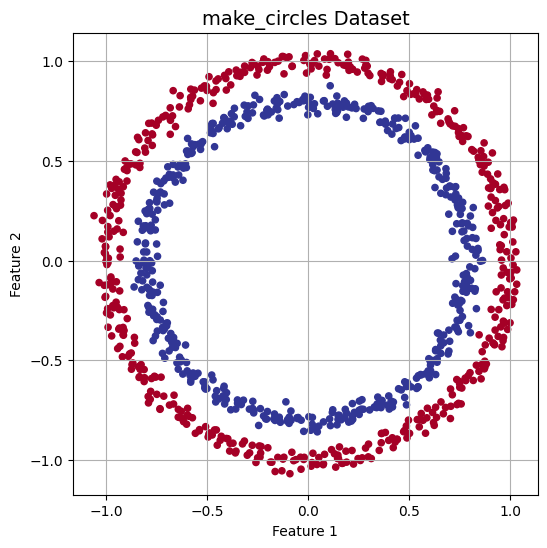

In [106]:
# Plot the data to see the circular pattern
plt.figure(figsize=(6,6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, s=20)
plt.title("make_circles Dataset", fontsize=14)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

 Step 5: Convert to DataFrame (Optional but Useful for Pandas Users)

In [107]:
# Create a pandas DataFrame for better readability
circles = pd.DataFrame({
    "X1": X[:, 0],
    "X2": X[:, 1],
    "label": y
})

# Display the first 10 rows of the DataFrame
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


## 1.1 Check input and output shapes

In [108]:
X.shape,y.shape

((1000, 2), (1000,))

In [109]:
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [110]:
# Views the first sample of feature and labels
X_sample = X[0]
y_sample = y[0]

print(f"Values for one sample of x:{X_sample} and the same for y:{y_sample}")
print(f"Shapes for one sample of x:{X_sample.shape} and the same for y:{y_sample.shape}")

Values for one sample of x:[0.75424625 0.23148074] and the same for y:1
Shapes for one sample of x:(2,) and the same for y:()


## 1.2 Turns data into tensors and create train test splits

In [111]:
# (right now our data is in NumPy arrays and PyTorch prefers to work with PyTorch tensors).
# Turn data into tensors for being used with PyTorch and for modelling.
# Otherwise this causes issues with computations later on
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# View the first five samples
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [112]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2, # 20% test, 80% train
                                                    random_state=42) # make the random split reproducible

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

## 1.3. Building a Classification Model with PyTorch
We now have the data prepared. Let's build a simple neural network model using PyTorch.

This step includes:

1. Setting up device-agnostic code

2. Creating a custom model class by subclassing nn.Module

3. Building the same model using nn.Sequential

4. Making initial predictions before training



In [113]:
# Standard PyTorch imports
from torch import nn

# Set device to GPU if available, otherwise fallback to CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


 Step 2: Create a Custom Model Class

* We'll build a simple neural network with two linear layers:

In [114]:
# 1. Define a model class by subclassing nn.Module
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # First linear layer: input is 2D, output is 5D
        self.layer_1 = nn.Linear(in_features=2, out_features=5)
        # Second linear layer: input is 5D, output is 1D (binary classification output)
        self.layer_2 = nn.Linear(in_features=5, out_features=1)

    # 2. Define the forward pass logic
    def forward(self, x):
        return self.layer_2(self.layer_1(x))  # x -> layer_1 -> layer_2


Step 3: Instantiate and Move Model to Target Device

In [115]:
# 3. Create an instance of the model and move it to device (CPU/GPU)
model_0 = CircleModelV0().to(device)

# Check the model architecture
print(model_0)

# Check the device of model parameters
print(f"Model is on device: {next(model_0.parameters()).device}")

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)
Model is on device: cpu


Alternate Method: Using `nn.Sequential`

* If you prefer a cleaner syntax, you can use nn.Sequential to chain layers together.

In [116]:
# Define the same model using nn.Sequential
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

# View model structure
print(model_0)

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)


In [117]:
# View model parameters
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.0910, -0.6231],
                      [ 0.2968, -0.1061],
                      [-0.3239,  0.6074],
                      [ 0.1576, -0.3912],
                      [-0.3579, -0.0338]])),
             ('0.bias', tensor([ 0.3948, -0.1807, -0.4035, -0.2421, -0.5283])),
             ('1.weight',
              tensor([[ 0.1595,  0.3462, -0.4210,  0.1039,  0.2310]])),
             ('1.bias', tensor([0.0811]))])

Step 4: Make Predictions Before Training

In [118]:

# Make predictions using the untrained model
untrained_preds = model_0(X_test.to(device))

# Print basic info
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test labels: {len(y_test)}, Shape: {y_test.shape}")


Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test labels: 200, Shape: torch.Size([200])


In [119]:

# View first 10 predictions and labels
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")


First 10 predictions:
tensor([[-0.2666],
        [-0.3156],
        [ 0.1111],
        [-0.3747],
        [ 0.5070],
        [ 0.4741],
        [ 0.0224],
        [ 0.2084],
        [ 0.0938],
        [-0.3145]], grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [120]:
# Optional: View the raw input and label pairs
X_test[:10], y_test[:10]

(tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438],
         [ 0.6323, -0.5711],
         [ 0.8561,  0.5499],
         [ 1.0034,  0.1903],
         [-0.7489, -0.2951],
         [ 0.0538,  0.9739]]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

# 2. Set Up Loss Function and Optimizer
Before training the model, we need to:

* Define a loss function that tells us how far off our model’s predictions are.

* Choose an optimizer to update the model's weights based on the gradients.

* Create a utility function to calculate the accuracy of our model.

### PyTorch Loss Functions and Optimizers
different problem types require different loss functions. here are Table of various loss functions and optimizers,



| **Loss function/Optimizer**                         | **Problem type**                     | **PyTorch Code**                                    |
|-----------------------------------------------------|--------------------------------------|-----------------------------------------------------|
| Stochastic Gradient Descent (SGD) optimizer         | Classification, regression, many others | `torch.optim.SGD()`                            |
| Adam Optimizer                                      | Classification, regression, many others | `torch.optim.Adam()`                           |
| Binary cross entropy loss                           | Binary classification                 | `torch.nn.BCELossWithLogits` or `torch.nn.BCELoss` |
| Cross entropy loss                                  | Multi-class classification            | `torch.nn.CrossEntropyLoss`                      |
| Mean absolute error (MAE) or L1 Loss                | Regression                            | `torch.nn.L1Loss`                                |
| Mean squared error (MSE) or L2 Loss                 | Regression                            | `torch.nn.MSELoss`                               |


## 2.1 Optimizer: Stochastic Gradient Descent

We’ll use Stochastic Gradient Descent (SGD), a simple and commonly used optimizer.

In [121]:
# Setup the loss function
#loss_fn = nn.BCELoss( ) # BCELoss = requires input to have gone through the sigmoid activation function prior to input to BCELoss.
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogisticsLoss = sigmoid activation function built-in

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1,
                            )

## 2.2 Model Parameters

In [122]:
# View the model's initial weights and biases
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.0910, -0.6231],
                      [ 0.2968, -0.1061],
                      [-0.3239,  0.6074],
                      [ 0.1576, -0.3912],
                      [-0.3579, -0.0338]])),
             ('0.bias', tensor([ 0.3948, -0.1807, -0.4035, -0.2421, -0.5283])),
             ('1.weight',
              tensor([[ 0.1595,  0.3462, -0.4210,  0.1039,  0.2310]])),
             ('1.bias', tensor([0.0811]))])

## 2.3 Accuracy Function

In [123]:
# Calculates accuracy in percentage
def accuracy_fn(y_true, y_pred):
    """
    Computes accuracy: (number of correct predictions / total predictions) * 100
    Assumes y_true and y_pred are of same shape and contain 0s and 1s.
    """
    correct = torch.eq(y_true, y_pred).sum().item()  # Count matching values
    acc = (correct / len(y_pred)) * 100  # Convert to percentage
    return acc

#3. Train Model

To train a PyTorch model, we use a training loop that repeats for multiple epochs. Each iteration follows this pattern:

**Training Loop Steps**

1.Forward pass – Get predictions (logits) from the model

2.Calculate loss – Compare predictions to ground truth

3.Zero gradients – Clear old gradients

4.Backward pass – Calculate gradients (backpropagation)

5.Step optimizer – Update the model's parameters using gradients

## 3.1 Logits → Prediction Probabilities → Prediction Labels

Since our model outputs raw logits (real-valued numbers), we need to:

* Convert them into probabilities using sigmoid() (for binary classification).

* Convert the probabilities into class labels using torch.round().

In [194]:
model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

 Inspect Model Outputs Before Training



In [195]:
# Set model to evaluation mode (disables dropout, etc.)
model_0.eval()

# Disable gradient tracking during inference
with torch.inference_mode():
    # Get raw logits for first 5 test samples
    y_logits = model_0(X_test.to(device))[:5]

# Print raw logits
print("Raw Logits:")
print(y_logits)

# Compare with true labels
print("True Labels:")
print(y_test[:5])



Raw Logits:
tensor([[-0.1050],
        [-0.1127],
        [-0.0231],
        [-0.1285],
        [ 0.0751]])
True Labels:
tensor([1., 0., 1., 0., 1.])


 Convert Logits to Prediction Probabilities

In [196]:
# Apply sigmoid to convert logits to probabilities
y_pred_probs = torch.sigmoid(y_logits)

print("Predicted Probabilities:")
print(y_pred_probs)

Predicted Probabilities:
tensor([[0.4738],
        [0.4719],
        [0.4942],
        [0.4679],
        [0.5188]])


Convert Prediction Probabilities to Predicted Labels

To turn our prediction probabilities into prediction labels, we can round the outputs of the sigmoid activation function.

More specificially:

*  If y_pred_probs >= 0.5, y=1 (class 1)
*  If y_pred_probs < 0.5, y=0 (class 0)


In [197]:
# Round prediction probabilities to get class labels (0 or 1)
y_preds = torch.round(y_pred_probs)

print("Predicted Labels:")
print(y_preds)

Predicted Labels:
tensor([[0.],
        [0.],
        [0.],
        [0.],
        [1.]])


Full Inference in One Line

In [198]:
# Full prediction pipeline for entire test set
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))))


Check for Equality

In [199]:
# Check if both methods produce the same labels
print("Are the predictions identical?")
print(torch.eq(y_preds.squeeze(), y_pred_labels[:5].squeeze()))

Are the predictions identical?
tensor([True, True, True, True, True])


Remove Extra Dimension

In [200]:
# Remove extra dimensions from predictions
y_preds = y_preds.squeeze()

# View predicted vs. true labels
print("Predicted Labels (squeezed):", y_preds)
print("True Labels:", y_test[:5])

Predicted Labels (squeezed): tensor([0., 0., 0., 0., 1.])
True Labels: tensor([1., 0., 1., 0., 1.])


## 3.2 Building Training and Testing Loop Explained (Epochs)
This section is where learning happens. We loop through the data multiple times (called epochs) and update the model weights using backpropagation and gradient descent.

Setup Before the Loop

In [201]:
# Set random seeds for reproducibility
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
epochs = 100

# Move data to the target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Training and evaluation loop
for epoch in range(epochs):
    # === Training ===
    model_0.train()  # Set model to training mode

    # 1. Forward pass (returns raw logits)
    y_logits = model_0(X_train).squeeze()  # Remove extra dimension
    y_pred = torch.round(torch.sigmoid(y_logits))  # Logits -> Probabilities -> Labels

    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_train)  # BCEWithLogitsLoss uses raw logits
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # 3. Zero gradients
    optimizer.zero_grad()

    # 4. Backpropagation
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    # === Evaluation ===
    model_0.eval()  # Set model to evaluation mode
    with torch.inference_mode():  # Disable gradient calculation
        # 1. Forward pass on test set
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. Calculate loss and accuracy
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    # Print metrics every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 2675.19678, Accuracy: 48.62% | Test loss: 529.75781, Test acc: 51.50%
Epoch: 10 | Loss: 2675.19678, Accuracy: 48.62% | Test loss: 529.75781, Test acc: 51.50%
Epoch: 20 | Loss: 2675.19678, Accuracy: 48.62% | Test loss: 529.75781, Test acc: 51.50%
Epoch: 30 | Loss: 2675.19678, Accuracy: 48.62% | Test loss: 529.75781, Test acc: 51.50%
Epoch: 40 | Loss: 2675.19678, Accuracy: 48.62% | Test loss: 529.75781, Test acc: 51.50%
Epoch: 50 | Loss: 2675.19678, Accuracy: 48.62% | Test loss: 529.75781, Test acc: 51.50%
Epoch: 60 | Loss: 2675.19678, Accuracy: 48.62% | Test loss: 529.75781, Test acc: 51.50%
Epoch: 70 | Loss: 2675.19678, Accuracy: 48.62% | Test loss: 529.75781, Test acc: 51.50%
Epoch: 80 | Loss: 2675.19678, Accuracy: 48.62% | Test loss: 529.75781, Test acc: 51.50%
Epoch: 90 | Loss: 2675.19678, Accuracy: 48.62% | Test loss: 529.75781, Test acc: 51.50%


**Summary of Training Loop**

| Step                  | Purpose                                |
| --------------------- | -------------------------------------- |
| `.train()`            | Enables training-specific behavior     |
| `model(input)`        | Forward pass through the model         |
| `loss_fn(...)`        | Computes how wrong the predictions are |
| `.zero_grad()`        | Clears old gradients                   |
| `.backward()`         | Backpropagation – calculate gradients  |
| `.step()`             | Gradient descent – update weights      |
| `.eval()`             | Turns off training-specific behavior   |
| `with inference_mode` | Improves efficiency during testing     |


#4. Make Prediction and evaluate the model and Plot Decision Boundary

To check how well our model is separating the data, we’ll use `plot_decision_boundary()`.

* Step 1: Download helper_functions.py if not present

In [202]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


import plotting functions

Plot decision boundary for train and test sets

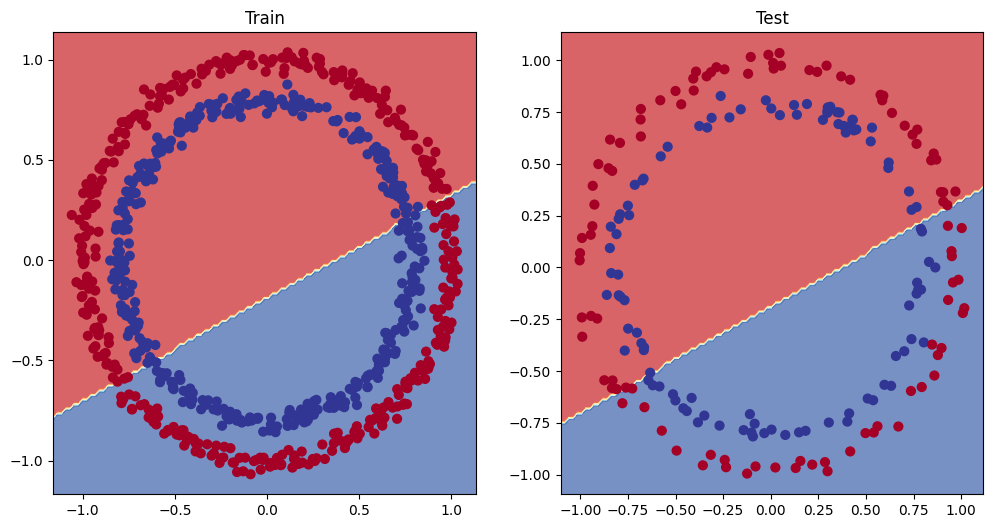

In [203]:
import matplotlib.pyplot as plt

# Plot decision boundaries
plt.figure(figsize=(12, 6))

# Training data
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)

# Test data
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

plt.show()

# 5. Improving the Model (from a Model Perspective)

We can improve a neural network by tuning its structure and training setup. These are called **hyperparameters** — values we, as developers, choose.

### Key Hyperparameter Tweaks:

- **More hidden units:** Increase from 5 → 10
- **More layers:** Increase from 2 → 3
- **Train longer:** More epochs (100 → 1000)

These help the model better learn patterns in the data.

---

### 🔧 Model Improvement Techniques

| **Technique**                   | **Purpose**                                                                                   |
|-------------------------------|-----------------------------------------------------------------------------------------------|
| **Add more layers**           | Helps the model learn more complex features (makes it deeper).                                |
| **Add more hidden units**     | Allows more learning per layer (makes it wider).                                              |
| **More epochs**               | Gives the model more chances to learn from the data.                                          |
| **Change activation function**| Helps model fit non-linear patterns (ReLU, Tanh, etc.).                                       |
| **Adjust learning rate**      | Controls update step size; too high → unstable, too low → slow learning.                      |
| **Change loss function**      | Matching the right loss function to the problem improves learning (e.g., BCE vs MSE).         |
| **Use transfer learning**     | Start from a pretrained model to save time and improve performance on related tasks.          |

---

We'll now apply:
- More layers
- More hidden units
- More training time


In [134]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.0853, -0.6054],
                      [ 0.2702, -0.0136],
                      [-0.2974,  0.5168],
                      [ 0.1534, -0.3777],
                      [-0.3785,  0.0385]])),
             ('0.bias', tensor([ 0.3914, -0.1811, -0.4003, -0.2444, -0.5273])),
             ('1.weight',
              tensor([[-0.0199,  0.3061, -0.2382, -0.0171,  0.2606]])),
             ('1.bias', tensor([0.0824]))])

Define a Custom Model with Multiple Layers

In [135]:
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        # Layer 1: input 2 features → 10 hidden units
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        # Layer 2: hidden → hidden
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        # Layer 3: hidden → 1 output
        self.layer_3 = nn.Linear(in_features=10, out_features=1)

    def forward(self, x):
        # Pass data through each layer
        return self.layer_3(self.layer_2(self.layer_1(x)))
# Instantiate model and move it to device (CPU or GPU)
model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

Model Setup

In [136]:
# Binary Cross Entropy Loss with Logits (no need for separate sigmoid)
loss_fn = nn.BCEWithLogitsLoss()

# SGD Optimizer with learning rate
optimizer = torch.optim.SGD(model_1.parameters(), lr=0.1)



Training and Evaluation Loop

In [137]:
torch.manual_seed(42)

epochs = 1000 # Train for longer

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    ### Training
    # 1. Forward pass
    y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> prediction probabilities -> prediction labels

    # 2. Calculate loss/accuracy
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train,
                      y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_1.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_1(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        # 2. Caculate loss/accuracy
        test_loss = loss_fn(test_logits,
                            y_test)
        test_acc = accuracy_fn(y_true=y_test,
                               y_pred=test_pred)

    # Print out what's happening every 10 epochs
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.69396, Accuracy: 50.88% | Test loss: 0.69261, Test acc: 51.00%
Epoch: 100 | Loss: 0.69305, Accuracy: 50.38% | Test loss: 0.69379, Test acc: 48.00%
Epoch: 200 | Loss: 0.69299, Accuracy: 51.12% | Test loss: 0.69437, Test acc: 46.00%
Epoch: 300 | Loss: 0.69298, Accuracy: 51.62% | Test loss: 0.69458, Test acc: 45.00%
Epoch: 400 | Loss: 0.69298, Accuracy: 51.12% | Test loss: 0.69465, Test acc: 46.00%
Epoch: 500 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69467, Test acc: 46.00%
Epoch: 600 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 700 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 800 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch: 900 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69468, Test acc: 46.00%


Visualize Decision Boundary

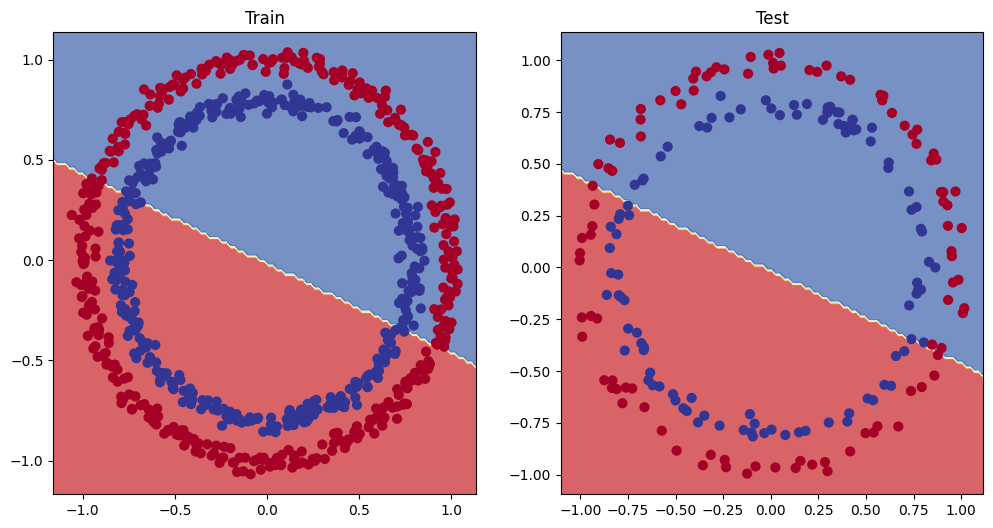

In [138]:
plt.figure(figsize=(12, 6))

# Train set
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)

# Test set
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)


## 5.1 Preparing data to see if our model can model a straight line


In [139]:
# Create some data (same as notebook 01)
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

# Create data
X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias # linear regression formula

# Check the data
print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [140]:
# Split the dataset: 80% for training, 20% for testing
train_split = int(0.8 * len(X_regression))
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]


In [141]:
# Check number of samples in each set
print("Train set:", len(X_train_regression), len(y_train_regression))
print("Test set:", len(X_test_regression), len(y_test_regression))


Train set: 80 80
Test set: 20 20


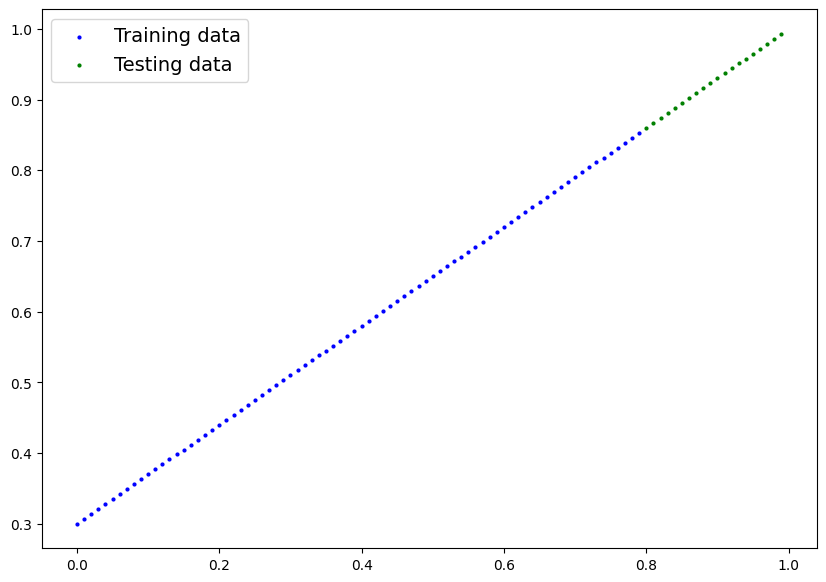

In [142]:
# (Optional) Visualize the training and testing data
plot_predictions(
    train_data=X_train_regression,
    train_labels=y_train_regression,
    test_data=X_test_regression,
    test_labels=y_test_regression
)

In [143]:
X_train_regression[:10], y_train_regression[:10]

(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400],
         [0.0500],
         [0.0600],
         [0.0700],
         [0.0800],
         [0.0900]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280],
         [0.3350],
         [0.3420],
         [0.3490],
         [0.3560],
         [0.3630]]))

## 5.2 Adjusting `model_1` to fit a straight line

We'll create a new model (model_2) with:

* 3 layers (more depth)

* More hidden units (10 instead of 5)

In [144]:
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [145]:
 # Same architecture as model_1 (but using nn.Sequential)
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [146]:
# Define loss function (L1 Loss = Mean Absolute Error)
loss_fn = nn.L1Loss()

# Use SGD optimizer with a learning rate of 0.1
optimizer = torch.optim.SGD(model_2.parameters(), lr=0.1)

Explanation:

* L1 Loss: Measures absolute difference between predicted and true values.

* SGD (Stochastic Gradient Descent): Optimizer that updates model parameters using gradients.

* `nn.Sequential`: Clean way to stack layers without writing a full model class.

##5.3 Training the Model to Learn a Straight Line

In [186]:
# Train the model
torch.manual_seed(42)

# Set the number of epochs
epochs = 1000

# Put data to target device
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):
    ### Training
    # 1. Forward pass
    y_pred = model_2(X_train_regression)

    # 2. Calculate loss (no accuracy since it's a regression problem, not classification)
    loss = loss_fn(y_pred, y_train_regression)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_2.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_pred = model_2(X_test_regression)
      # 2. Calculate the loss
      test_loss = loss_fn(test_pred, y_test_regression)

    # Print out what's happening
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss:.5f}, Test loss: {test_loss:.5f}")

Epoch: 0 | Train loss: -0.00000, Test loss: -0.00000
Epoch: 100 | Train loss: -0.00000, Test loss: -0.00000
Epoch: 200 | Train loss: -0.00000, Test loss: -0.00000
Epoch: 300 | Train loss: -0.00000, Test loss: -0.00000
Epoch: 400 | Train loss: -0.00000, Test loss: -0.00000
Epoch: 500 | Train loss: -0.00000, Test loss: -0.00000
Epoch: 600 | Train loss: -0.00000, Test loss: -0.00000
Epoch: 700 | Train loss: -0.00000, Test loss: -0.00000
Epoch: 800 | Train loss: -0.00000, Test loss: -0.00000
Epoch: 900 | Train loss: -0.00000, Test loss: -0.00000


##5.4 Evaluate and Visualize Model Predictions

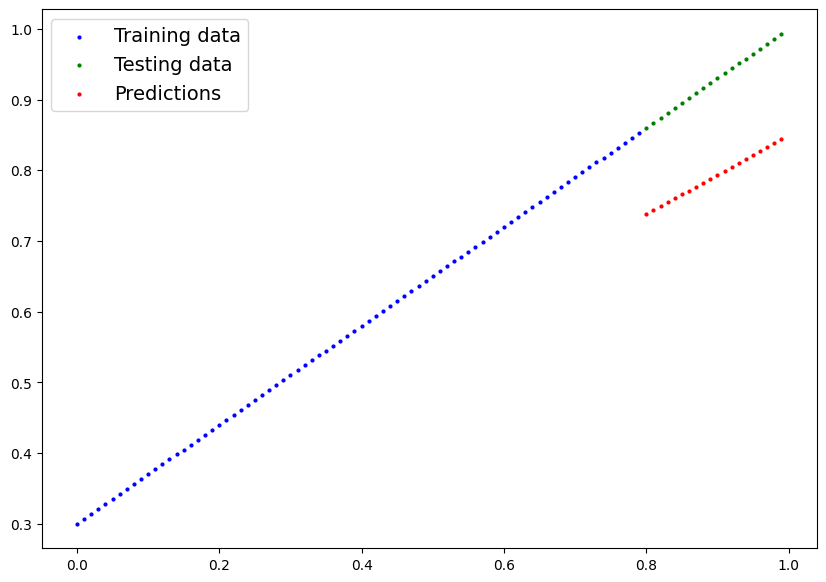

In [148]:
# Turn on evaluation mode
model_2.eval()

# Make predictions (inference)
with torch.inference_mode():
    y_preds = model_2(X_test_regression)

# Plot data and predictions with data on the CPU (matplotlib can't handle data on the GPU)
# (try removing .cpu() from one of the below and see what happens)
plot_predictions(train_data=X_train_regression.cpu(),
                 train_labels=y_train_regression.cpu(),
                 test_data=X_test_regression.cpu(),
                 test_labels=y_test_regression.cpu(),
                 predictions=y_preds.cpu());

#6. The missing piece: non-linearity

In deep learning, non-linearity helps models learn more complex patterns—beyond straight lines.


* Neural networks are a combination of linear and non-linear operations.
Without non-linear functions like ReLU or Sigmoid, a neural network would be no better than a simple linear model.

##6.1 Recreating non-linear data(red and blue circles)

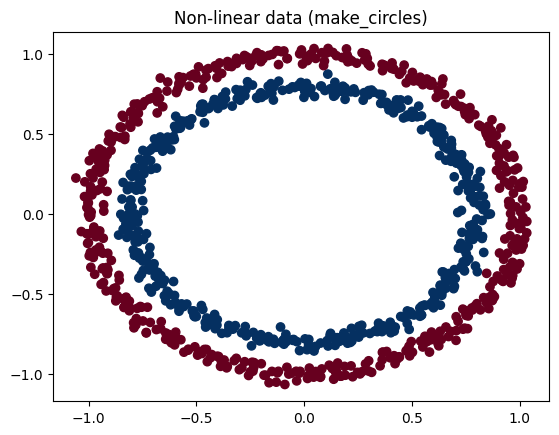

In [187]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

# Generate circular data (two classes in concentric circles)
n_samples = 1000
X, y = make_circles(n_samples=n_samples, noise=0.03, random_state=42)

# Visualize the circular data
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu)
plt.title("Non-linear data (make_circles)")
plt.show()

Convert Data to Tensors and Split into Train/Test Sets

In [188]:
from sklearn.model_selection import train_test_split

# Convert NumPy arrays to PyTorch tensors
X = torch.from_numpy(X).type(torch.float32)
y = torch.from_numpy(y).type(torch.float32)

# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Preview training samples
X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

##6.2 Building a Model with Non-Linearity

In [151]:
from torch import nn

# Define a model with non-linear ReLU activation functions
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(2, 10)
        self.layer_2 = nn.Linear(10, 10)
        self.layer_3 = nn.Linear(10, 1)
        self.relu = nn.ReLU()  # ReLU adds non-linearity

    def forward(self, x):
        # Forward pass with ReLU applied after each layer except last
        return self.layer_3(
            self.relu(self.layer_2(
                self.relu(self.layer_1(x)))
            )
        )

# Instantiate model and move to device
model_3 = CircleModelV2().to(device)
print(model_3)


CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


Set Up Loss and Optimizer

In [152]:
# Setup loss and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_3.parameters(), lr=0.1)


##6.3 Training a model with non-linearity

In [153]:
len(X_test), len(y_test)

(200, 200)

In [154]:
# Fit the model
torch.manual_seed(42)
epochs = 1000

# Put all data on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    # 1. Forward pass
    y_logits = model_3(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> prediction probabilities -> prediction labels

    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_train) # BCEWithLogitsLoss calculates loss using logits
    acc = accuracy_fn(y_true=y_train,
                      y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_3.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_logits = model_3(X_test).squeeze()
      test_pred = torch.round(torch.sigmoid(test_logits)) # logits -> prediction probabilities -> prediction labels
      # 2. Calculate loss and accuracy
      test_loss = loss_fn(test_logits, y_test)
      test_acc = accuracy_fn(y_true=y_test,
                             y_pred=test_pred)

    # Print out what's happening
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.69295, Accuracy: 50.00% | Test Loss: 0.69319, Test Accuracy: 50.00%
Epoch: 100 | Loss: 0.69115, Accuracy: 52.88% | Test Loss: 0.69102, Test Accuracy: 52.50%
Epoch: 200 | Loss: 0.68977, Accuracy: 53.37% | Test Loss: 0.68940, Test Accuracy: 55.00%
Epoch: 300 | Loss: 0.68795, Accuracy: 53.00% | Test Loss: 0.68723, Test Accuracy: 56.00%
Epoch: 400 | Loss: 0.68517, Accuracy: 52.75% | Test Loss: 0.68411, Test Accuracy: 56.50%
Epoch: 500 | Loss: 0.68102, Accuracy: 52.75% | Test Loss: 0.67941, Test Accuracy: 56.50%
Epoch: 600 | Loss: 0.67515, Accuracy: 54.50% | Test Loss: 0.67285, Test Accuracy: 56.00%
Epoch: 700 | Loss: 0.66659, Accuracy: 58.38% | Test Loss: 0.66322, Test Accuracy: 59.00%
Epoch: 800 | Loss: 0.65160, Accuracy: 64.00% | Test Loss: 0.64757, Test Accuracy: 67.50%
Epoch: 900 | Loss: 0.62362, Accuracy: 74.00% | Test Loss: 0.62145, Test Accuracy: 79.00%


##6.4 Evaluating a model trained with non-linear activation functions


In [189]:
# Make predictions
model_3.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()
y_preds[:10], y[:10] # want preds in same format as truth labels

(tensor([1., 0., 1., 0., 0., 1., 0., 0., 1., 0.]),
 tensor([1., 1., 1., 1., 0., 1., 1., 1., 1., 0.]))

Plotting Decision Boundaries

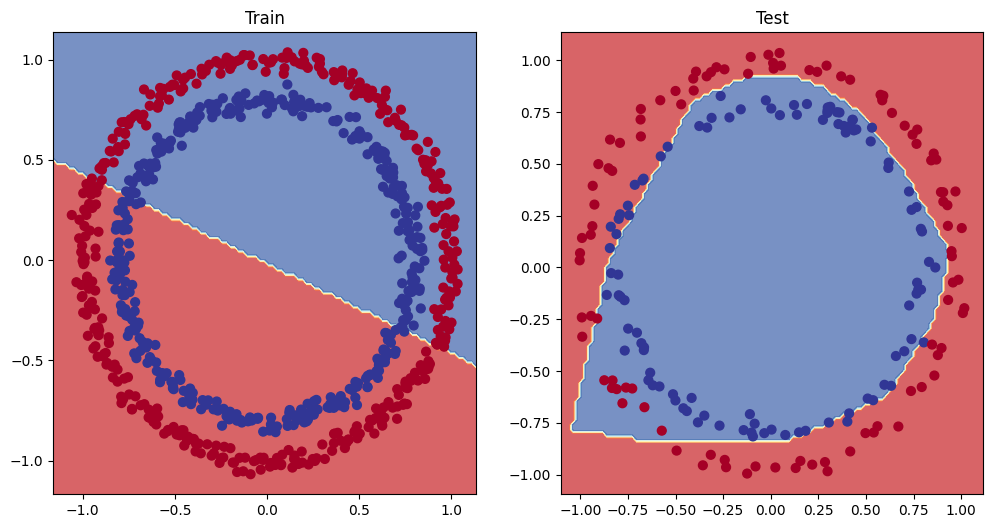

In [190]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train) # model_1 = no non-linearity
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test) # model_3 = has non-linearity

# 7. Exploring Non-linear Activation Functions in Neural Networks

In neural networks, we use **activation functions** to introduce **non-linearity**, which helps the model learn complex patterns in data.

Let’s visualize two commonly used activation functions: **ReLU (Rectified Linear Unit)** and **Sigmoid**.


In [191]:
# Create a Tensor
A = torch.arange(-10,10,1,dtype=torch.float32)
A.dtype

torch.float32

In [192]:
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

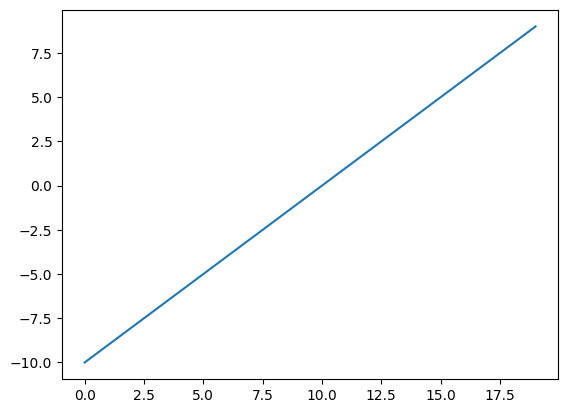

In [193]:
# Visualise the tensor
plt.plot(A);

## 7.1 ReLU Activation Function (Rectified Linear Unit)

- ReLU outputs `0` for negative values and keeps positive values unchanged.
- This helps the network stay simple while avoiding vanishing gradients.


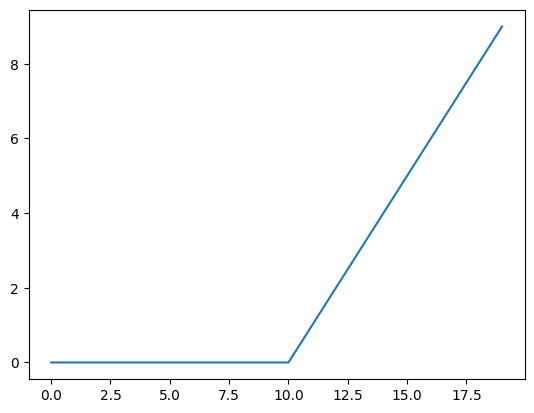

In [160]:
plt.plot(torch.relu(A))

In [161]:
def relu(x: torch.Tensor):
    return torch.maximum(torch.tensor(0),x) # inputs must be tensors
relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

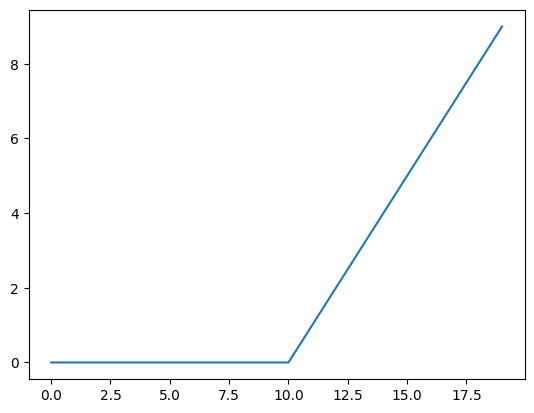

In [162]:
# plot Relu activation function
plt.plot(torch.relu(A))

## 7.2 Sigmoid Activation Function

- Sigmoid maps input values to the range (0, 1).
- Commonly used in binary classification problems.


In [163]:
def sigmoid(x):
  return 1/(1+torch.exp(-x))

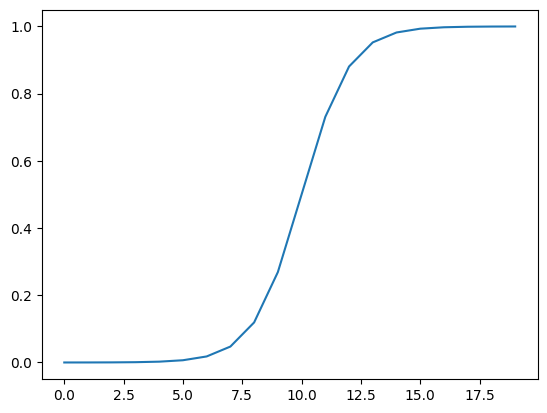

In [164]:
plt.plot(torch.sigmoid(A))

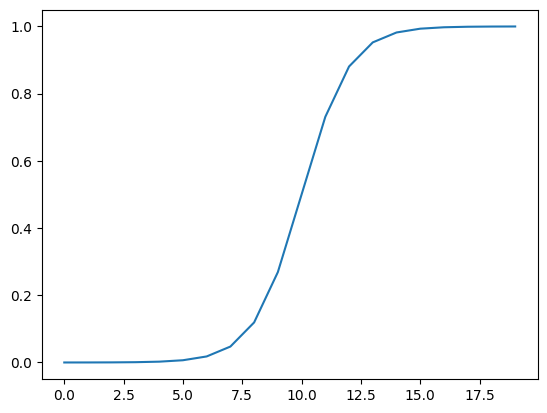

In [165]:
plt.plot(sigmoid(A))

# 8. Multi-class Classification in PyTorch

## Binary Classification: 0 or 1 (e.g., spam or not spam)
## Multi-class Classification: 3 or more classes (e.g., cat vs. dog vs. chicken)


##8.1 Creating Multi-class Data
We'll use make_blobs() to create synthetic data with 4 different classes.

tensor([[-8.4134,  6.9352],
        [-5.7665, -6.4312],
        [-6.0421, -6.7661],
        [ 3.9508,  0.6984],
        [ 4.2505, -0.2815]]) tensor([3, 2, 2, 1, 1])


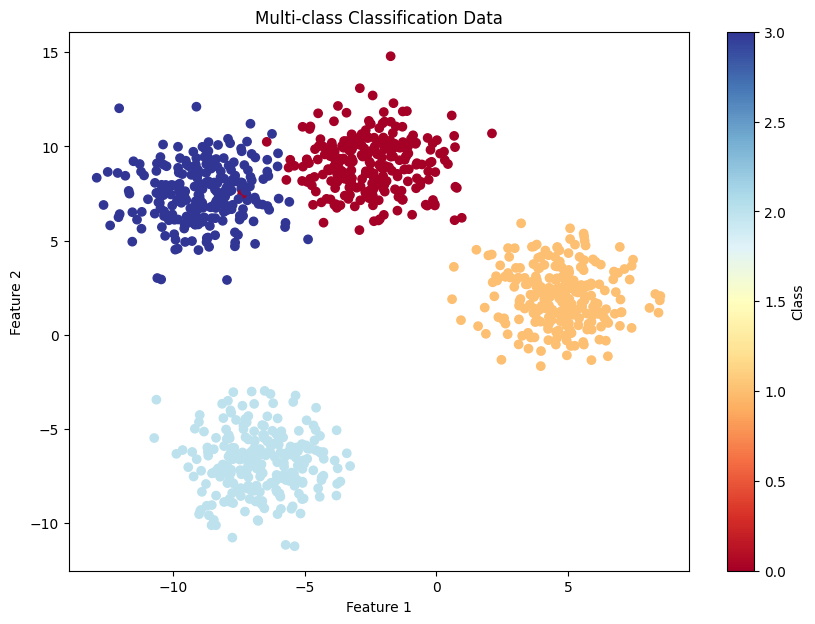

In [166]:

# Set the hyperparameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. Create multi-class data
X_blob, y_blob = make_blobs(n_samples=1000,
    n_features=NUM_FEATURES, # X features
    centers=NUM_CLASSES, # y labels
    cluster_std=1.5, # give the clusters a little shake up (try changing this to 1.0, the default)
    random_state=RANDOM_SEED
)

# 2. Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)
print(X_blob[:5], y_blob[:5])

# 3. Split into train and test sets
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
    y_blob,
    test_size=0.2,
    random_state=RANDOM_SEED
)


# 4. Visualize the data
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu)
plt.title("Multi-class Classification Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Class")
plt.show()

##8.2 Building the Multi-class Classification Model

We'll use `nn.Sequential` and add `ReLU` non-linearities between layers.


In [167]:
# Create device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [168]:

# Build model
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        """Initializes all required hyperparameters for a multi-class classification model.

        Args:
            input_features (int): Number of input features to the model.
            out_features (int): Number of output features of the model
              (how many classes there are).
            hidden_units (int): Number of hidden units between layers, default 8.
        """
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(), # <- does our dataset require non-linear layers? (try uncommenting and see if the results change)
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(), # <- does our dataset require non-linear layers? (try uncommenting and see if the results change)
            nn.Linear(in_features=hidden_units, out_features=output_features), # how many classes are there?
        )

    def forward(self, x):
        return self.linear_layer_stack(x)

# Create an instance of BlobModel and send it to the target device
model_4 = BlobModel(input_features=NUM_FEATURES,
                    output_features=NUM_CLASSES,
                    hidden_units=8).to(device)
model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

## 8.3 Setting the Loss Function and Optimizer

Since this is a multi-class classification problem, we use:
- `CrossEntropyLoss` (for multi-class classification)
- `SGD` optimizer

In [169]:
# Create loss and optimizer
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model_4.parameters(),
                            lr=0.1) # exercise: try changing the learning rate here and seeing what happens to the model's performance

## 8.4 Making Predictions and Getting Probabilities

Let's perform a forward pass through the model and convert the logits (raw scores) into probabilities using `softmax`.


In [170]:
# lET'S get some raw outputs of our model (logits)
model_4.eval()
with torch.inference_mode():
    y_preds = model_4(X_blob_test.to(device))

y_preds[:10]

tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834],
        [-0.1497, -1.0617, -0.7107, -0.1645],
        [ 0.1539, -0.2887,  0.1520, -0.0109],
        [-0.2154, -1.1795, -0.9300, -0.2745],
        [ 0.2443, -0.2472,  0.1649,  0.0061],
        [-0.2329, -1.2120, -0.9849, -0.3004]])

In [171]:
y_blob_test[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

In [172]:
X_blob_test.device

device(type='cpu')

In [173]:
next(model_4.parameters()).device

device(type='cpu')

In [174]:
# Perform a single forward pass on the data (we'll need to put it to the target device for it to work)
model_4(X_blob_train.to(device))[:5]

tensor([[-0.7586, -0.6810, -1.5180, -1.1178],
        [-0.2398, -1.2335, -0.9858, -0.2899],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [ 0.2391, -0.2472,  0.1494,  0.0213],
        [-0.1214, -0.9804, -0.6918, -0.1923]], grad_fn=<SliceBackward0>)

In [175]:
# How many elements in a single prediction sample?
model_4(X_blob_train.to(device))[0].shape, NUM_CLASSES

(torch.Size([4]), 4)

In [176]:
# Make prediction logits with model
y_logits = model_4(X_blob_test.to(device))

# Perform softmax calculation on logits across dimension 1 to get prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834]], grad_fn=<SliceBackward0>)
tensor([[0.3169, 0.3244, 0.1405, 0.2182],
        [0.3336, 0.1432, 0.2026, 0.3206],
        [0.3011, 0.1843, 0.2823, 0.2323],
        [0.3078, 0.2766, 0.1836, 0.2320],
        [0.3719, 0.1286, 0.1532, 0.3463]], grad_fn=<SliceBackward0>)


In [177]:
# Sum the first sample output of the softmax activation function
torch.sum(y_pred_probs[0])

tensor(1.0000, grad_fn=<SumBackward0>)

In [178]:
# Which class does the model think is *most* likely at the index 0 sample?
print(y_pred_probs[0])
print(torch.argmax(y_pred_probs[0]))

tensor([0.3169, 0.3244, 0.1405, 0.2182], grad_fn=<SelectBackward0>)
tensor(1)


##8.5 Creating a training and testing loop for a multi-class PyTorch model

In [179]:
y_blob_train.dtype

torch.int64

In [180]:
# Fit the model
torch.manual_seed(42)

# Set number of epochs
epochs = 100

# Put data to target device
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
    ### Training
    model_4.train()

    # 1. Forward pass
    y_logits = model_4(X_blob_train) # model outputs raw logits
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # go from logits -> prediction probabilities -> prediction labels
    # print(y_logits)
    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy_fn(y_true=y_blob_train,
                      y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_4.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_logits = model_4(X_blob_test)
      test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
      # 2. Calculate test loss and accuracy
      test_loss = loss_fn(test_logits, y_blob_test)
      test_acc = accuracy_fn(y_true=y_blob_test,
                             y_pred=test_pred)

    # Print out what's happening
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 1.15883, Acc: 40.38% | Test Loss: 1.07554, Test Acc: 48.00%
Epoch: 10 | Loss: 0.64476, Acc: 96.75% | Test Loss: 0.66069, Test Acc: 97.50%
Epoch: 20 | Loss: 0.42535, Acc: 98.50% | Test Loss: 0.43074, Test Acc: 100.00%
Epoch: 30 | Loss: 0.25294, Acc: 99.12% | Test Loss: 0.24508, Test Acc: 99.50%
Epoch: 40 | Loss: 0.11232, Acc: 99.25% | Test Loss: 0.10229, Test Acc: 99.50%
Epoch: 50 | Loss: 0.06627, Acc: 99.25% | Test Loss: 0.05848, Test Acc: 99.50%
Epoch: 60 | Loss: 0.05068, Acc: 99.25% | Test Loss: 0.04293, Test Acc: 99.50%
Epoch: 70 | Loss: 0.04300, Acc: 99.25% | Test Loss: 0.03491, Test Acc: 99.50%
Epoch: 80 | Loss: 0.03836, Acc: 99.25% | Test Loss: 0.02988, Test Acc: 99.50%
Epoch: 90 | Loss: 0.03525, Acc: 99.25% | Test Loss: 0.02663, Test Acc: 99.50%


##8.6 Making and evaluating predictions with a PyTorch multi-class model

In [181]:
# Make predictions
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(X_blob_test)

# View the first 10 predictions
y_logits[:10]

tensor([[-0.6249,  5.9860, -7.6323, -8.4470],
        [-2.1738, -6.3750, -3.7202,  3.1203],
        [-3.4102, -3.8958,  3.1567, -2.6119],
        [-1.1505,  4.1962, -3.8472, -4.8820],
        [ 3.7548, -1.3391, -9.1422, -6.9466],
        [-2.8211, -7.5767, -4.2944,  3.7944],
        [-3.0306, -3.3328,  2.7955, -2.1374],
        [ 3.3761, -4.0375, -6.8987, -3.5503],
        [-4.3620, -4.9904,  3.8123, -3.3814],
        [ 3.5012, -3.0281, -7.5401, -4.7064]])

In [182]:
# Turn predicted logits in prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)

# Turn prediction probabilities into prediction labels
y_preds = y_pred_probs.argmax(dim=1)

# Compare first 10 model preds and test labels
print(f"Predictions: {y_preds[:10]}\nLabels: {y_blob_test[:10]}")
print(f"Test accuracy: {accuracy_fn(y_true=y_blob_test, y_pred=y_preds)}%")

Predictions: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])
Labels: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])
Test accuracy: 99.5%


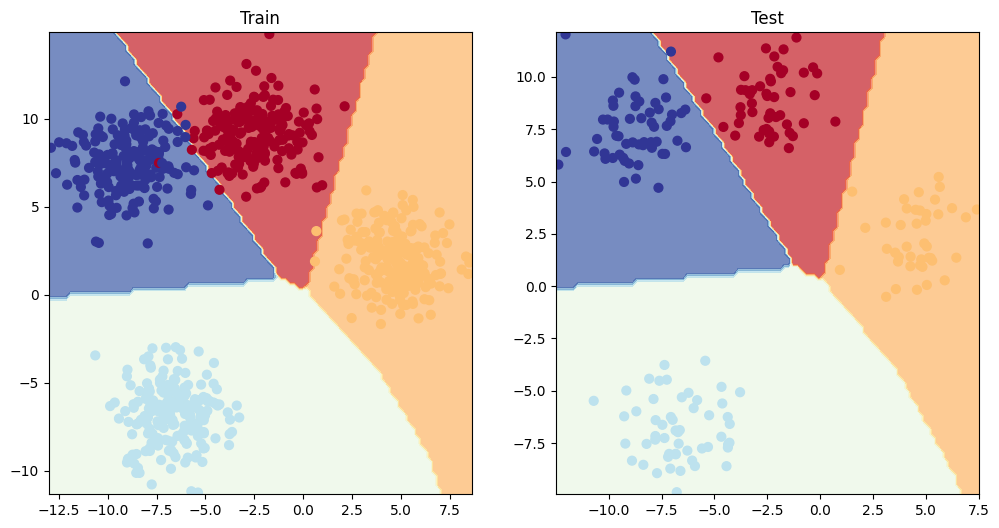

In [183]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)

#9. Classification evaluation metrics

### Model Evaluation Metrics

| **Metric name/Evaluation method** | **Definition** | **Code** |
|----------------------------------|----------------|----------|
| **Accuracy** | Out of 100 predictions, how many does your model get correct? E.g. 95% accuracy means it gets 95/100 predictions correct. | `torchmetrics.Accuracy()`<br>or<br>`sklearn.metrics.accuracy_score()` |
| **Precision** | Proportion of true positives over total number of samples. Higher precision leads to less false positives (model predicts 1 when it should've been 0). | `torchmetrics.Precision()`<br>or<br>`sklearn.metrics.precision_score()` |
| **Recall** | Proportion of true positives over total number of true positives and false negatives (model predicts 0 when it should've been 1). Higher recall leads to less false negatives. | `torchmetrics.Recall()`<br>or<br>`sklearn.metrics.recall_score()` |
| **F1-score** | Combines precision and recall into one metric. 1 is best, 0 is worst. | `torchmetrics.F1Score()`<br>or<br>`sklearn.metrics.f1_score()` |
| **Confusion matrix** | Compares the predicted values with the true values in a tabular way. If 100% correct, all values in the matrix will be top left to bottom right (diagonal line). | `torchmetrics.ConfusionMatrix`<br>or<br>`sklearn.metrics.plot_confusion_matrix()` |
| **Classification report** | Collection of some of the main classification metrics such as precision, recall and f1-score. | `sklearn.metrics.classification_report()` |


In [184]:
try:
    from torchmetrics import Accuracy
except:
    !pip install torchmetrics==0.9.3 # this is the version we're using in this notebook (later versions exist here: https://torchmetrics.readthedocs.io/en/stable/generated/CHANGELOG.html#changelog)
    from torchmetrics import Accuracy

# Setup metric and make sure it's on the target device
torchmetrics_accuracy = Accuracy(task='multiclass', num_classes=4).to(device)

# Calculate accuracy
torchmetrics_accuracy(y_preds, y_blob_test)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.6/419.6 kB 10.9 MB/s eta 0:00:00


tensor(0.9950)